# Round 1 EDA — Bot Behavior & Order Book Analysis
**Products:** `ASH_COATED_OSMIUM` · `INTARIAN_PEPPER_ROOT`  
**Focus:** Book structure at each timestamp · Fixed-qty bot fingerprints · Exploitable patterns

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# ── Style ──────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#0d1117',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#e6edf3',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#e6edf3',
    'grid.color':       '#21262d',
    'grid.linestyle':   '--',
    'axes.titlecolor':  '#e6edf3',
    'axes.titlesize':   11,
    'axes.labelsize':   9,
    'font.size':        9,
    'figure.dpi':       110,
})

C_BID   = '#3fb950'   # green  — bids
C_ASK   = '#f85149'   # red    — asks
C_FV    = '#58a6ff'   # blue   — fair value
C_TRADE = '#d29922'   # gold   — trades
C_MID   = '#bc8cff'   # purple — mid/other
DAYS    = [-2, -1, 0]
PRODUCTS = ['ASH_COATED_OSMIUM', 'INTARIAN_PEPPER_ROOT']
DRIFT   = 0.001       # PEPPER_ROOT: +1000 per day, 0.001 per tick
DAY_START = {-2: 10000, -1: 11000, 0: 12000}

# ── Load data ──────────────────────────────────────────────────────────────────
prices = {}
trades = {}
for day in DAYS:
    prices[day] = pd.read_csv(f'../data/ROUND1/prices_round_1_day_{day}.csv', sep=';')
    trades[day] = pd.read_csv(f'../data/ROUND1/trades_round_1_day_{day}.csv', sep=';')

def wall_mid(df):
    bp = df[['bid_price_1','bid_price_2','bid_price_3']].values
    bv = df[['bid_volume_1','bid_volume_2','bid_volume_3']].values
    ap = df[['ask_price_1','ask_price_2','ask_price_3']].values
    av = df[['ask_volume_1','ask_volume_2','ask_volume_3']].values
    bvf = np.where(np.isnan(bv), -1, bv)
    avf = np.where(np.isnan(av), -1, av)
    wb = bp[np.arange(len(df)), np.argmax(bvf, axis=1)]
    wa = ap[np.arange(len(df)), np.argmax(avf, axis=1)]
    return (wb + wa) / 2

def get_sub(product, day):
    df = prices[day][prices[day]['product'] == product].copy().reset_index(drop=True)
    df['wm'] = wall_mid(df)
    if product == 'INTARIAN_PEPPER_ROOT':
        df['fv'] = DAY_START[day] + df['timestamp'] * DRIFT
        df['detrend'] = df['wm'] - df['fv']
    else:
        df['fv'] = 10000.0
        df['detrend'] = df['wm'] - 10000
    df['spread1'] = df['ask_price_1'] - df['bid_price_1']
    return df

def get_trades(product, day):
    t = trades[day][trades[day]['symbol'] == product].copy()
    return t

print('Data loaded.')
for d in DAYS:
    print(f'  Day {d}: {len(prices[d])} price rows, {len(trades[d])} trade rows')

Data loaded.
  Day -2: 20000 price rows, 773 trade rows
  Day -1: 20000 price rows, 760 trade rows
  Day 0: 20000 price rows, 743 trade rows


---
## Section 1 — Price & Spread Overview
Fair value, wall_mid, and L1 spread across all 3 days for both products.

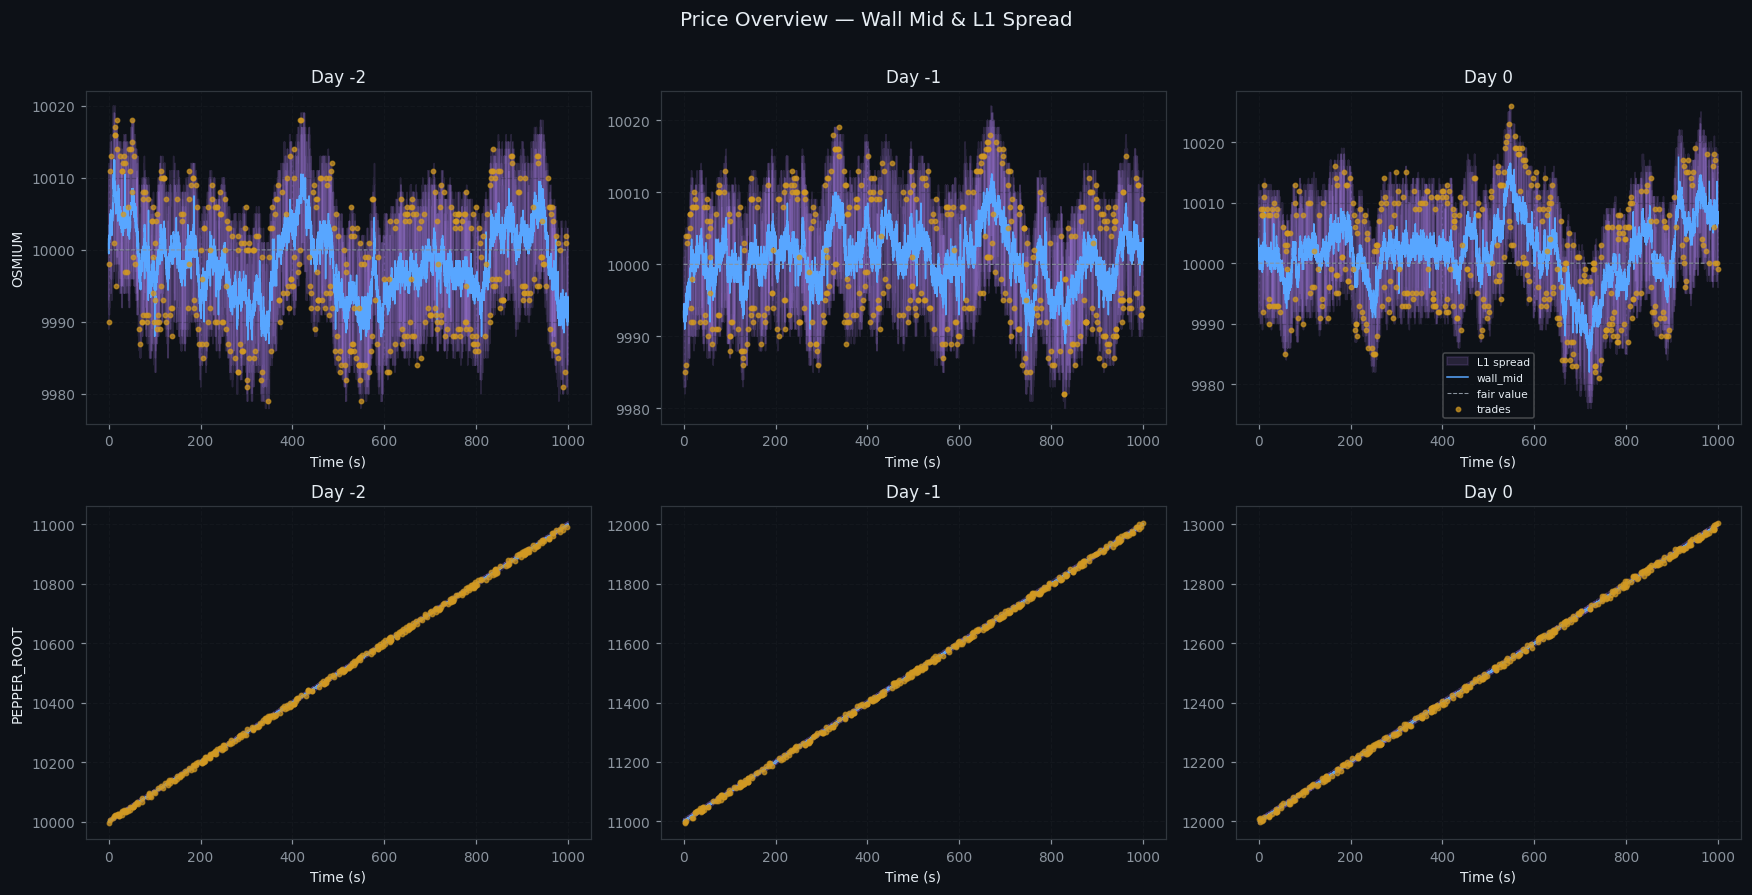

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Price Overview — Wall Mid & L1 Spread', y=1.01, fontsize=13, color='#e6edf3')
fig.patch.set_facecolor('#0d1117')

for row, prod in enumerate(PRODUCTS):
    for col, day in enumerate(DAYS):
        ax = axes[row][col]
        df = get_sub(prod, day)
        t  = get_trades(prod, day)
        ts  = df['timestamp'] / 1000  # seconds

        # Band: bid-ask L1
        ax.fill_between(ts, df['bid_price_1'], df['ask_price_1'],
                        alpha=0.15, color=C_MID, label='L1 spread')
        ax.plot(ts, df['wm'], color=C_FV, lw=1.0, label='wall_mid')
        ax.plot(ts, df['fv'], color='#8b949e', lw=0.7, ls='--', label='fair value')

        # Trades
        if len(t) > 0:
            ax.scatter(t['timestamp']/1000, t['price'], c=C_TRADE,
                       s=8, zorder=5, alpha=0.7, label='trades')

        ax.set_title(f'Day {day}', color='#e6edf3')
        if col == 0:
            short_name = prod.replace('INTARIAN_', '').replace('ASH_COATED_', '')
            ax.set_ylabel(short_name, color='#e6edf3')
        ax.set_xlabel('Time (s)')
        ax.grid(True, alpha=0.3)
        if row == 0 and col == 2:
            ax.legend(fontsize=7, framealpha=0.3)

plt.tight_layout()
plt.show()

---
## Section 2 — Detrended Price (residual around fair value)
Removes the deterministic +1000/day drift for PEPPER_ROOT. Shows the mean-reversion structure.

ASH_COATED_OSMIUM: lag-1 ACF across days: ['-0.434', '-0.434', '-0.419']
INTARIAN_PEPPER_ROOT: lag-1 ACF across days: ['-0.474', '-0.463', '-0.452']


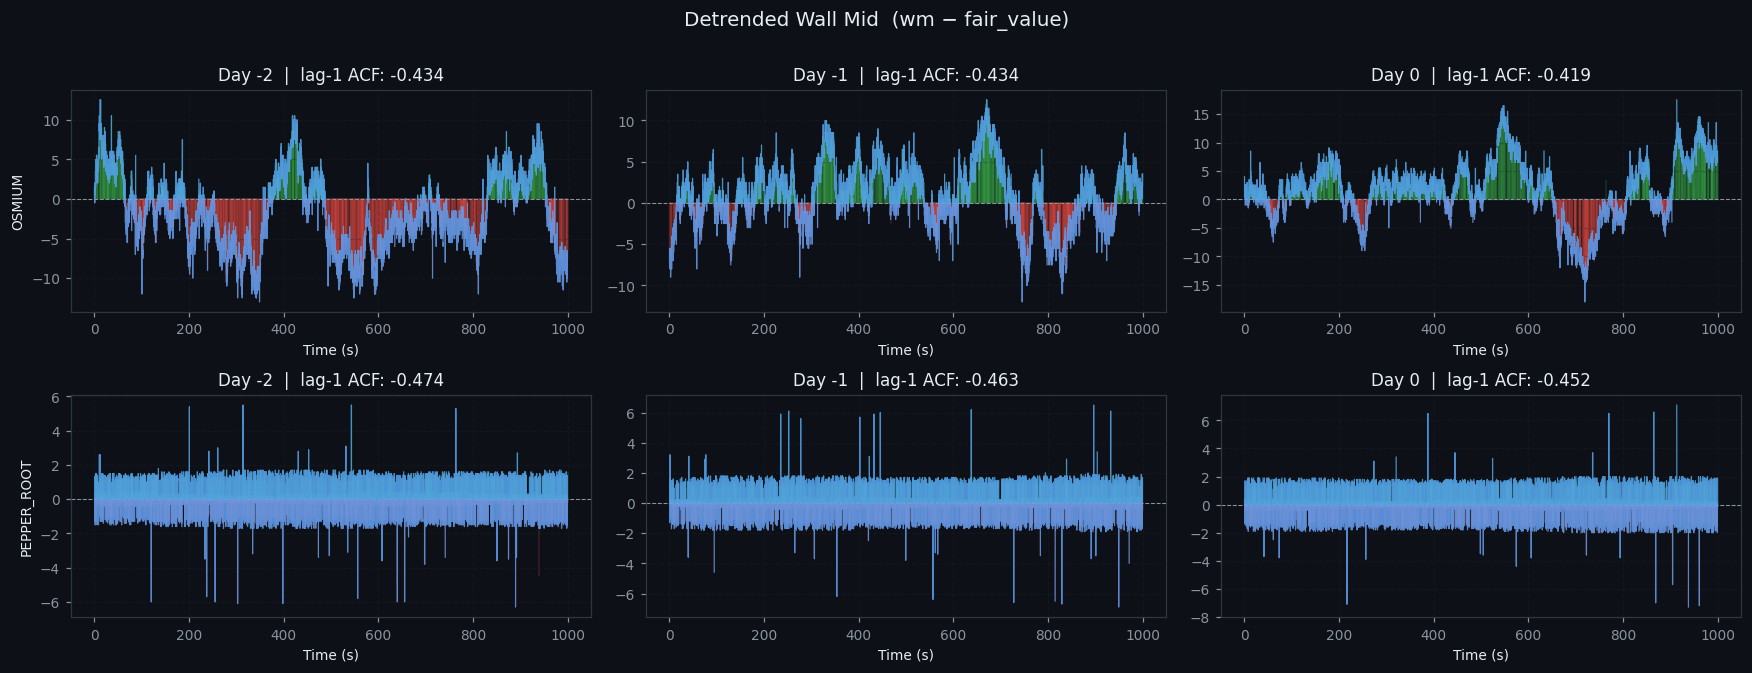

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(16, 6))
fig.suptitle('Detrended Wall Mid  (wm − fair_value)', y=1.01, fontsize=13)
fig.patch.set_facecolor('#0d1117')

for row, prod in enumerate(PRODUCTS):
    acfs_all = []
    for col, day in enumerate(DAYS):
        ax = axes[row][col]
        df = get_sub(prod, day)
        ts = df['timestamp'] / 1000
        det = df['detrend']

        ax.axhline(0, color='#8b949e', lw=0.7, ls='--')
        ax.plot(ts, det, color=C_FV, lw=0.7, alpha=0.8)
        ax.fill_between(ts, det, 0, where=det>0, alpha=0.2, color=C_BID)
        ax.fill_between(ts, det, 0, where=det<0, alpha=0.2, color=C_ASK)

        lag1 = pd.Series(det).diff().dropna().autocorr(1)
        ax.set_title(f'Day {day}  |  lag-1 ACF: {lag1:.3f}', color='#e6edf3')
        if col == 0:
            short = prod.replace('INTARIAN_','').replace('ASH_COATED_','')
            ax.set_ylabel(short)
        ax.set_xlabel('Time (s)')
        ax.grid(True, alpha=0.3)
        acfs_all.append(lag1)

    print(f'{prod}: lag-1 ACF across days: {[f"{a:.3f}" for a in acfs_all]}')
plt.tight_layout()
plt.show()

---
## Section 3 — Bot Volume Fingerprinting
Volume at each orderbook level tells you which bot placed the order.
**Key finding:** there are 2–3 distinct volume clusters per level — each cluster is a different bot type.

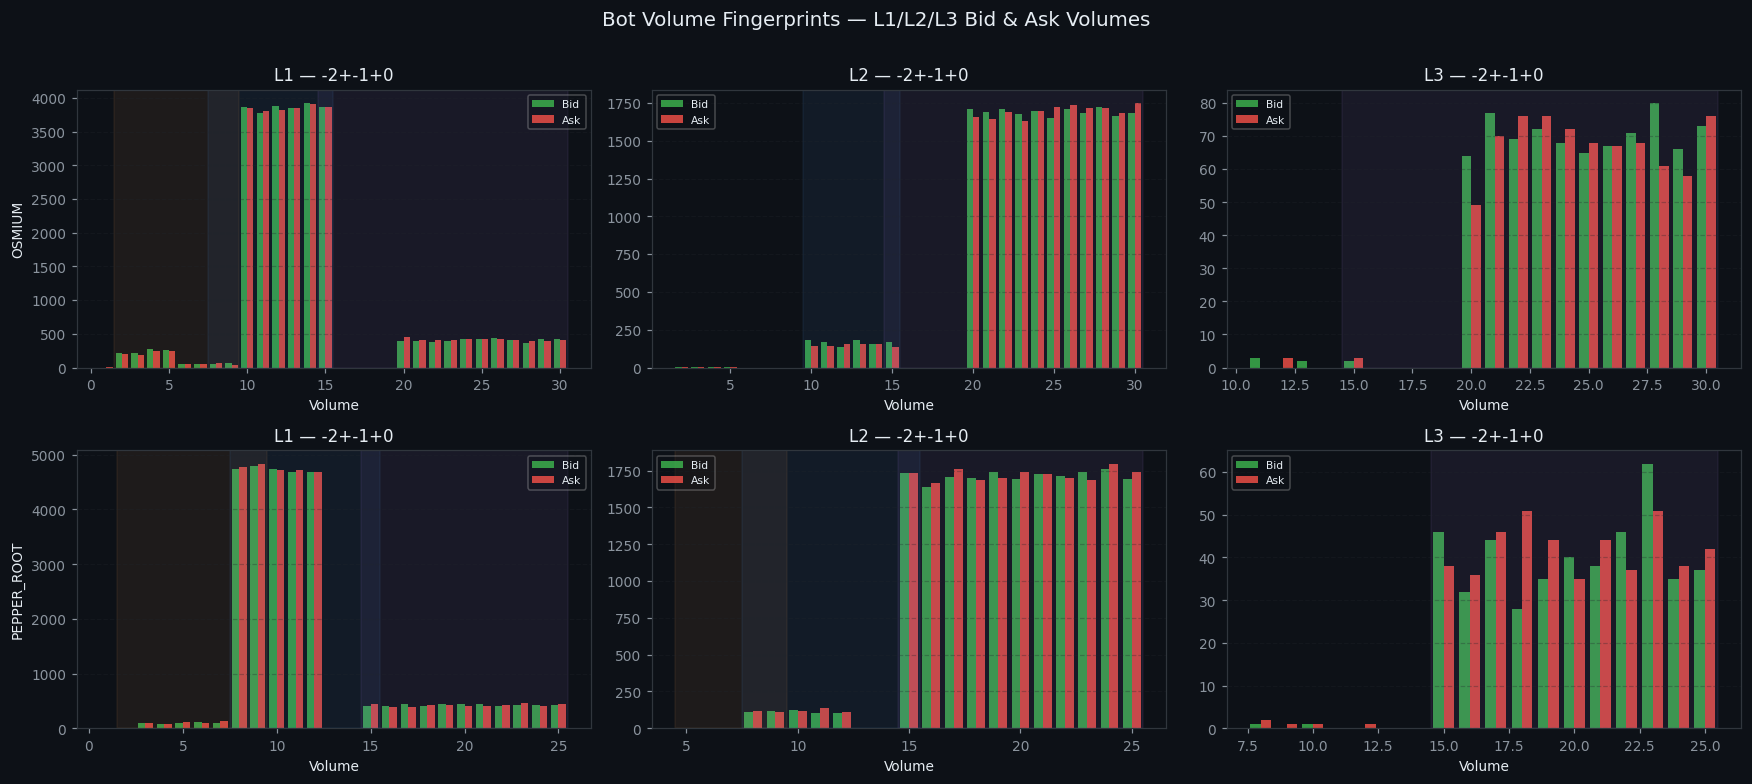


=== Volume cluster interpretation ===
Shaded region (orange/blue) = distinct bot population

PEPPER_ROOT:
  Vol 8-12  → MakerBot-A (main quotes, L1 when narrow spread)
  Vol 15-25 → MakerBot-B (wall quotes, L1 when wide spread)
  Vol 3-7   → Residual after taker fills (partially consumed)

OSMIUM:
  Vol 10-15 → MakerBot-A (active regime)
  Vol 20-30 → MakerBot-B (wall quotes, deep levels)
  Vol 2-9   → Residual after taker fills


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 7))
fig.suptitle('Bot Volume Fingerprints — L1/L2/L3 Bid & Ask Volumes', y=1.01, fontsize=13)
fig.patch.set_facecolor('#0d1117')

levels = [
    ('bid_volume_1', 'ask_volume_1', 'L1'),
    ('bid_volume_2', 'ask_volume_2', 'L2'),
    ('bid_volume_3', 'ask_volume_3', 'L3'),
]

for row, prod in enumerate(PRODUCTS):
    for col, (bv_col, av_col, label) in enumerate(levels):
        ax = axes[row][col]
        bvols, avols = [], []
        for day in DAYS:
            df = get_sub(prod, day)
            bvols.extend(df[bv_col].dropna().astype(int).tolist())
            avols.extend(df[av_col].dropna().astype(int).tolist())

        bvc = pd.Series(bvols).value_counts().sort_index()
        avc = pd.Series(avols).value_counts().sort_index()
        all_vols = sorted(set(bvc.index) | set(avc.index))

        x = np.array(all_vols)
        w = 0.4
        ax.bar(x - w/2, [bvc.get(v, 0) for v in all_vols], width=w,
               color=C_BID, alpha=0.8, label='Bid')
        ax.bar(x + w/2, [avc.get(v, 0) for v in all_vols], width=w,
               color=C_ASK, alpha=0.8, label='Ask')

        # Annotate clusters
        total_b = sum(bvc.values)
        for clust_range, color, name in [
            (range(2,10),   '#ffa657', 'TakerBot'),
            (range(8,16),   '#58a6ff', 'MakerBot-A'),
            (range(15,100), '#bc8cff', 'MakerBot-B'),
        ]:
            vs = [v for v in all_vols if v in clust_range]
            if vs:
                cnt = sum(bvc.get(v,0) for v in vs)
                if cnt > 50:
                    mid = np.mean(vs)
                    ax.axvspan(min(vs)-0.5, max(vs)+0.5, alpha=0.07, color=color)

        ax.set_title(f'{label} — {"+".join(str(d) for d in DAYS)}', color='#e6edf3')
        if col == 0:
            short = prod.replace('INTARIAN_','').replace('ASH_COATED_','')
            ax.set_ylabel(short)
        ax.set_xlabel('Volume')
        ax.legend(fontsize=7, framealpha=0.3)
        ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print()
print('=== Volume cluster interpretation ===')
print('Shaded region (orange/blue) = distinct bot population')
print()
print('PEPPER_ROOT:')
print('  Vol 8-12  → MakerBot-A (main quotes, L1 when narrow spread)')
print('  Vol 15-25 → MakerBot-B (wall quotes, L1 when wide spread)')
print('  Vol 3-7   → Residual after taker fills (partially consumed)')
print()
print('OSMIUM:')
print('  Vol 10-15 → MakerBot-A (active regime)')
print('  Vol 20-30 → MakerBot-B (wall quotes, deep levels)')
print('  Vol 2-9   → Residual after taker fills')

---
## Section 4 — Fixed-Quantity Bot Detection
Identify bots that always quote a specific volume. These are the ones we can front-run.

In [5]:
def detect_fixed_qty_bots(product, level_col, days=DAYS, min_pct=0.10):
    """
    Detect volume values that appear suspiciously often at a given order book level.
    Returns: dict of {volume: fraction_of_ticks}
    Anything above min_pct is a fixed-qty bot fingerprint.
    """
    vols = []
    for day in days:
        df = get_sub(product, day)
        vols.extend(df[level_col].dropna().astype(int).tolist())
    if not vols: return {}
    vc = pd.Series(vols).value_counts(normalize=True).sort_index()
    return {v: f for v, f in vc.items() if f >= min_pct}

print('=== FIXED-QTY BOT SIGNATURES (≥10% of ticks) ===')
print()
for prod in PRODUCTS:
    print(f'── {prod} ──')
    for level in ['bid_volume_1','ask_volume_1','bid_volume_2','ask_volume_2']:
        sigs = detect_fixed_qty_bots(prod, level)
        if sigs:
            sig_str = '  '.join(f'vol={v}: {100*f:.1f}%' for v,f in sorted(sigs.items(), key=lambda x:-x[1]))
            print(f'  {level:<18}: {sig_str}')
    print()

=== FIXED-QTY BOT SIGNATURES (≥10% of ticks) ===

── ASH_COATED_OSMIUM ──
  bid_volume_1      : vol=14: 13.6%  vol=12: 13.5%  vol=15: 13.4%  vol=10: 13.4%  vol=13: 13.4%  vol=11: 13.1%
  ask_volume_1      : vol=14: 13.6%  vol=15: 13.4%  vol=10: 13.4%  vol=13: 13.4%  vol=12: 13.3%  vol=11: 13.2%

── INTARIAN_PEPPER_ROOT ──
  bid_volume_1      : vol=9: 16.6%  vol=10: 16.5%  vol=8: 16.4%  vol=12: 16.3%  vol=11: 16.2%
  ask_volume_1      : vol=9: 16.8%  vol=8: 16.5%  vol=11: 16.3%  vol=10: 16.3%  vol=12: 16.3%



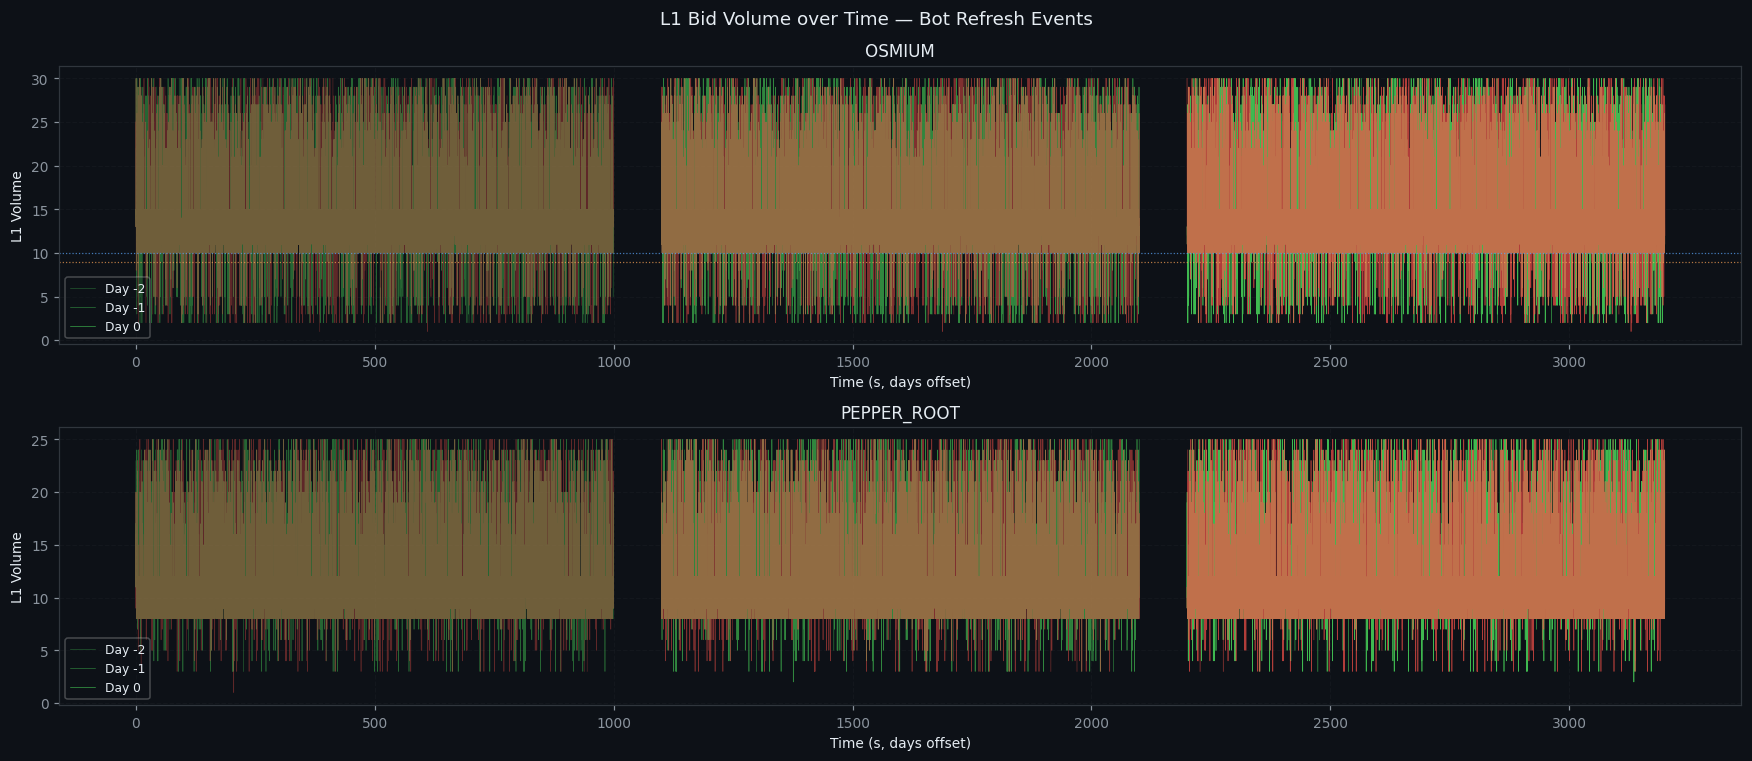

In [6]:
# Visualise the L1 volume time series — can you see bot refreshes?
fig, axes = plt.subplots(2, 1, figsize=(16, 7))
fig.patch.set_facecolor('#0d1117')
fig.suptitle('L1 Bid Volume over Time — Bot Refresh Events', fontsize=12)

for ax, prod in zip(axes, PRODUCTS):
    for day, alpha in [(-2, 0.5), (-1, 0.7), (0, 1.0)]:
        df = get_sub(prod, day)
        ts = df['timestamp'] / 1000 + (day + 2) * 1100  # offset days
        ax.plot(ts, df['bid_volume_1'], lw=0.4, alpha=alpha,
                color=C_BID, label=f'Day {day}')
        ax.plot(ts, df['ask_volume_1'], lw=0.4, alpha=alpha * 0.7,
                color=C_ASK)

    ax.set_title(prod.replace('INTARIAN_','').replace('ASH_COATED_',''), color='#e6edf3')
    ax.set_xlabel('Time (s, days offset)')
    ax.set_ylabel('L1 Volume')
    ax.legend(fontsize=8, framealpha=0.3)
    ax.grid(True, alpha=0.3)
    
    # Mark regime boundaries
    if prod == 'ASH_COATED_OSMIUM':
        ax.axhline(9, color='#ffa657', lw=0.8, ls=':', alpha=0.7, label='taker-fill boundary')
        ax.axhline(10, color='#58a6ff', lw=0.8, ls=':', alpha=0.7)
    
plt.tight_layout()
plt.show()

---
## Section 5 — Volume Regime: When Are Bots Being Filled?
Small volumes at L1 = a taker just partially filled the bot's quote. This is a fill-signal.

In [7]:
print('=== Volume Regime Interpretation ===')
print()

for prod in PRODUCTS:
    print(f'── {prod} ──')
    for day in DAYS:
        df = get_sub(prod, day)
        t  = get_trades(prod, day)

        # Define regime from L1 bid volume
        if prod == 'INTARIAN_PEPPER_ROOT':
            df['regime'] = pd.cut(df['bid_volume_1'],
                                  bins=[0, 7, 12, 100],
                                  labels=['small (3–7)', 'mid (8–12)', 'large (15–25)'])
        else:
            df['regime'] = pd.cut(df['bid_volume_1'],
                                  bins=[0, 9, 15, 100],
                                  labels=['small (2–9)', 'mid (10–15)', 'large (20–30)'])

        regime_stats = df.groupby('regime').agg(
            count=('timestamp', 'count'),
            spread=('spread1', 'mean'),
            detrend_std=('detrend', 'std'),
        ).round(2)
        print(f'  Day {day}:')
        print(regime_stats.to_string())

        # Check how many trades occur during each regime
        if len(t) > 0:
            ts_to_regime = dict(zip(df['timestamp'], df['regime']))
            t_regime = t['timestamp'].map(ts_to_regime)
            print(f'  Trades per regime: {t_regime.value_counts().to_dict()}')
    print()

=== Volume Regime Interpretation ===

── ASH_COATED_OSMIUM ──
  Day -2:
               count  spread  detrend_std
regime                                   
small (2–9)      403    9.89         4.71
mid (10–15)     7792   16.03         4.60
large (20–30)   1392   18.61         4.62
  Trades per regime: {'mid (10–15)': 337, 'large (20–30)': 63, 'small (2–9)': 22}
  Day -1:
               count  spread  detrend_std
regime                                   
small (2–9)      383    9.83         3.91
mid (10–15)     7697   16.03         3.67
large (20–30)   1522   18.61         3.69
  Trades per regime: {'mid (10–15)': 350, 'large (20–30)': 61, 'small (2–9)': 10}
  Day 0:
               count  spread  detrend_std
regime                                   
small (2–9)      398    9.72         5.41
mid (10–15)     7655   16.04         5.14
large (20–30)   1554   18.50         4.97
  Trades per regime: {'mid (10–15)': 318, 'large (20–30)': 72, 'small (2–9)': 13}

── INTARIAN_PEPPER_ROOT ──
  Day

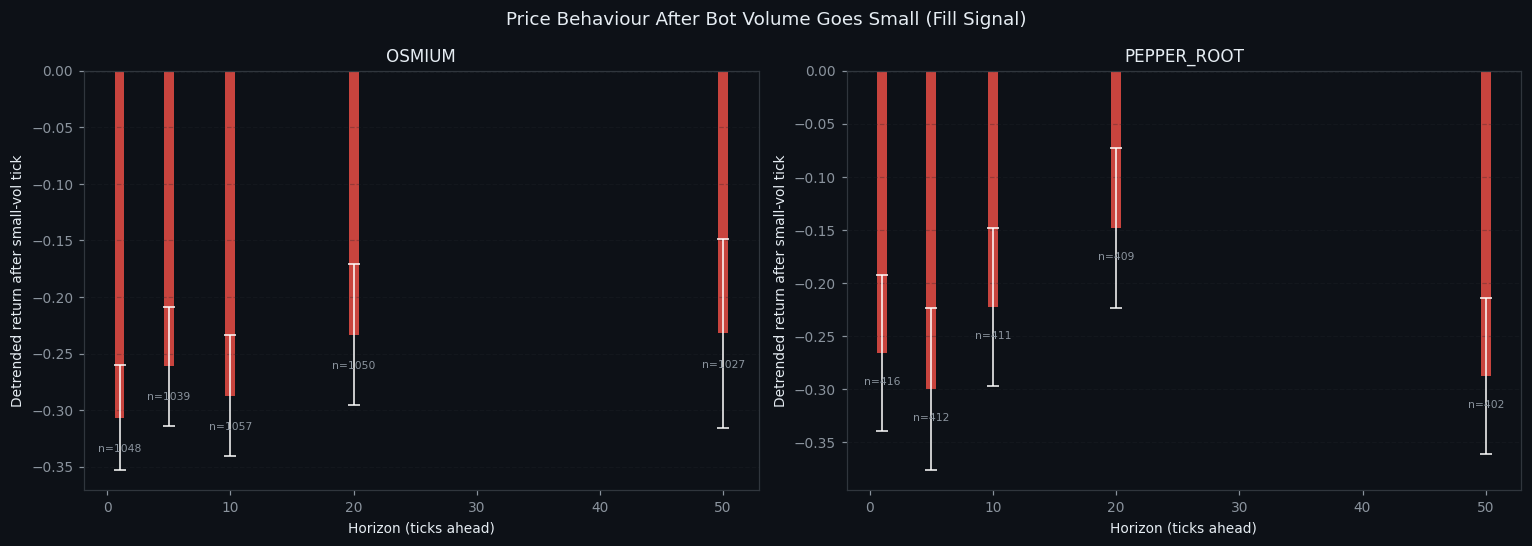

In [8]:
# When volume is SMALL (bot just got partially filled), what happens to price next?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0d1117')
fig.suptitle('Price Behaviour After Bot Volume Goes Small (Fill Signal)', fontsize=12)

for ax, prod in zip(axes, PRODUCTS):
    small_threshold = 7 if 'PEPPER' in prod else 9
    forward_rets = {k: [] for k in [1, 5, 10, 20, 50]}

    for day in DAYS:
        df = get_sub(prod, day)
        det = df.set_index('timestamp')['detrend']
        small_ticks = df[df['bid_volume_1'] <= small_threshold]
        
        for _, row in small_ticks.iterrows():
            ts = int(row['timestamp'])
            d0 = det.get(ts, np.nan)
            for k in forward_rets:
                dk = det.get(ts + k*100, np.nan)
                if not np.isnan(d0) and not np.isnan(dk):
                    forward_rets[k].append(dk - d0)

    horizons = sorted(forward_rets)
    means = [np.mean(forward_rets[k]) for k in horizons]
    stds  = [np.std(forward_rets[k])  for k in horizons]
    ns    = [len(forward_rets[k])     for k in horizons]

    ax.bar(horizons, means, color=[C_BID if m>0 else C_ASK for m in means], alpha=0.8)
    ax.errorbar(horizons, means, yerr=[s/np.sqrt(n) for s,n in zip(stds,ns)],
                fmt='none', color='white', capsize=4, lw=1)
    ax.axhline(0, color='white', lw=0.7, ls='--')
    ax.set_title(prod.replace('INTARIAN_','').replace('ASH_COATED_',''), color='#e6edf3')
    ax.set_xlabel('Horizon (ticks ahead)')
    ax.set_ylabel('Detrended return after small-vol tick')
    ax.grid(True, axis='y', alpha=0.3)
    for i, (h, m, n) in enumerate(zip(horizons, means, ns)):
        ax.text(h, m + (0.01 if m>=0 else -0.03), f'n={n}',
                ha='center', fontsize=7, color='#8b949e')

plt.tight_layout()
plt.show()

---
## Section 6 — Bid/Ask Price Offset Patterns
Bots post at specific offsets from fair value. Mapping these tells you EXACTLY what price they quote at.

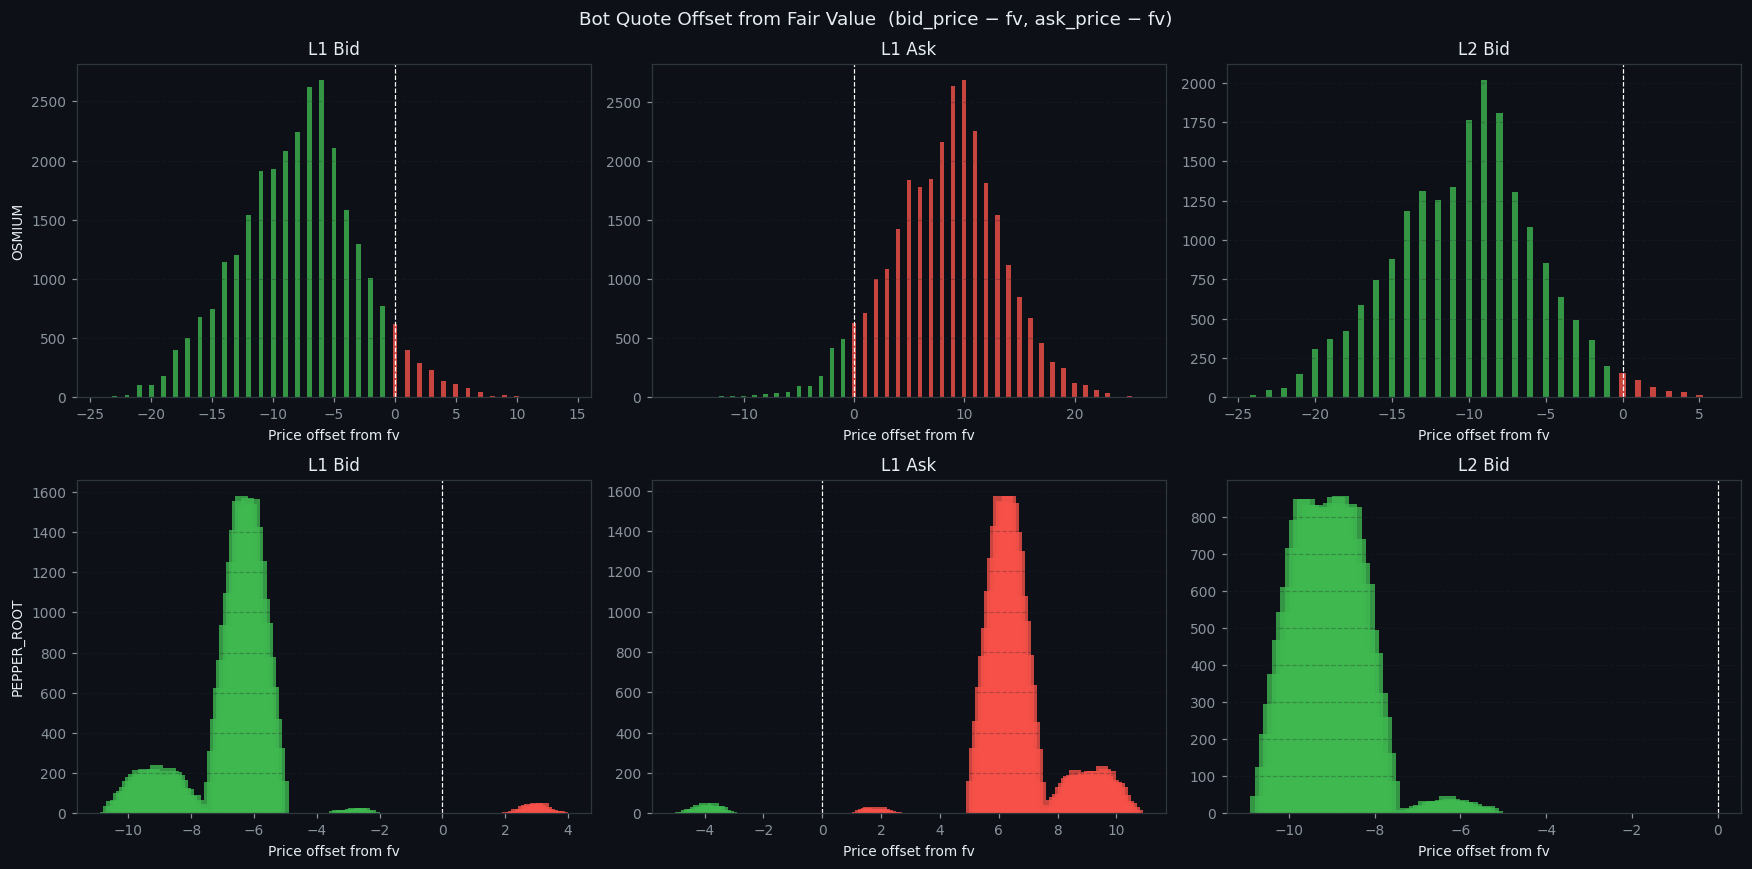

=== Most Common Bot Quote Offsets from Fair Value ===

ASH_COATED_OSMIUM:
  L1 Bid  : -6.0(9%), -7.0(9%), -8.0(8%), -5.0(7%), -9.0(7%)
  L1 Ask  : +10.0(9%), +9.0(9%), +11.0(8%), +8.0(8%), +7.0(6%)
  L2 Bid  : -9.0(10%), -8.0(9%), -10.0(9%), -11.0(7%), -13.0(7%)
  L2 Ask  : +12.0(10%), +11.0(9%), +13.0(9%), +10.0(7%), +8.0(7%)

INTARIAN_PEPPER_ROOT:
  L1 Bid  : -6.4(5%), -6.2(5%), -6.0(5%), -6.5(5%), -6.1(5%)
  L1 Ask  : +6.4(5%), +6.0(5%), +6.3(5%), +6.1(5%), +6.2(5%)
  L2 Bid  : -8.8(4%), -8.9(4%), -9.7(4%), -9.6(4%), -9.0(4%)
  L2 Ask  : +9.7(5%), +8.9(4%), +9.3(4%), +8.8(4%), +8.6(4%)


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.patch.set_facecolor('#0d1117')
fig.suptitle('Bot Quote Offset from Fair Value  (bid_price − fv, ask_price − fv)', fontsize=12)

levels = [('bid_price_1','bid_volume_1','L1 Bid'),
          ('ask_price_1','ask_volume_1','L1 Ask'),
          ('bid_price_2','bid_volume_2','L2 Bid')]

for row, prod in enumerate(PRODUCTS):
    for col, (price_col, vol_col, label) in enumerate(levels):
        ax = axes[row][col]
        offsets_by_vol = {}

        for day in DAYS:
            df = get_sub(prod, day)
            valid = df[[price_col, vol_col, 'fv']].dropna()
            valid['offset'] = (valid[price_col] - valid['fv']).round(1)
            valid['vol_int'] = valid[vol_col].astype(int)
            for vol, grp in valid.groupby('vol_int'):
                if vol not in offsets_by_vol:
                    offsets_by_vol[vol] = []
                offsets_by_vol[vol].extend(grp['offset'].tolist())

        # Pool and plot
        all_offsets = []
        for v, offs in offsets_by_vol.items():
            all_offsets.extend(offs)
        
        if all_offsets:
            offset_vc = pd.Series(all_offsets).value_counts().sort_index()
            mask_pos = offset_vc.index >= 0
            mask_neg = offset_vc.index < 0
            ax.bar(offset_vc.index[mask_neg], offset_vc.values[mask_neg],
                   color=C_BID, alpha=0.8, width=0.4)
            ax.bar(offset_vc.index[mask_pos], offset_vc.values[mask_pos],
                   color=C_ASK, alpha=0.8, width=0.4)
            ax.axvline(0, color='white', lw=0.8, ls='--')

        ax.set_title(label, color='#e6edf3')
        if col == 0:
            short = prod.replace('INTARIAN_','').replace('ASH_COATED_','')
            ax.set_ylabel(short)
        ax.set_xlabel('Price offset from fv')
        ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary of most common offsets
print('=== Most Common Bot Quote Offsets from Fair Value ===')
for prod in PRODUCTS:
    print(f'\n{prod}:')
    for price_col, label in [('bid_price_1','L1 Bid'), ('ask_price_1','L1 Ask'),
                               ('bid_price_2','L2 Bid'), ('ask_price_2','L2 Ask')]:
        offsets = []
        for day in DAYS:
            df = get_sub(prod, day)
            valid = df[[price_col,'fv']].dropna()
            offsets.extend((valid[price_col] - valid['fv']).round(1).tolist())
        vc = pd.Series(offsets).value_counts().head(5)
        top = ', '.join(f'{idx:+.1f}({100*cnt/len(offsets):.0f}%)' for idx,cnt in vc.items())
        print(f'  {label:<8}: {top}')

---
## Section 7 — Trade Analysis: Taker Bot Signatures
Named traders, size distribution, timing, and what happens to price after each trade.

=== Named Trader Scan (ALL days, ALL products) ===

ASH_COATED_OSMIUM:
  Named buyers:  (none — all anonymous)
  Named sellers: (none — all anonymous)
INTARIAN_PEPPER_ROOT:
  Named buyers:  (none — all anonymous)
  Named sellers: (none — all anonymous)

=== Trade Quantity Distribution ===



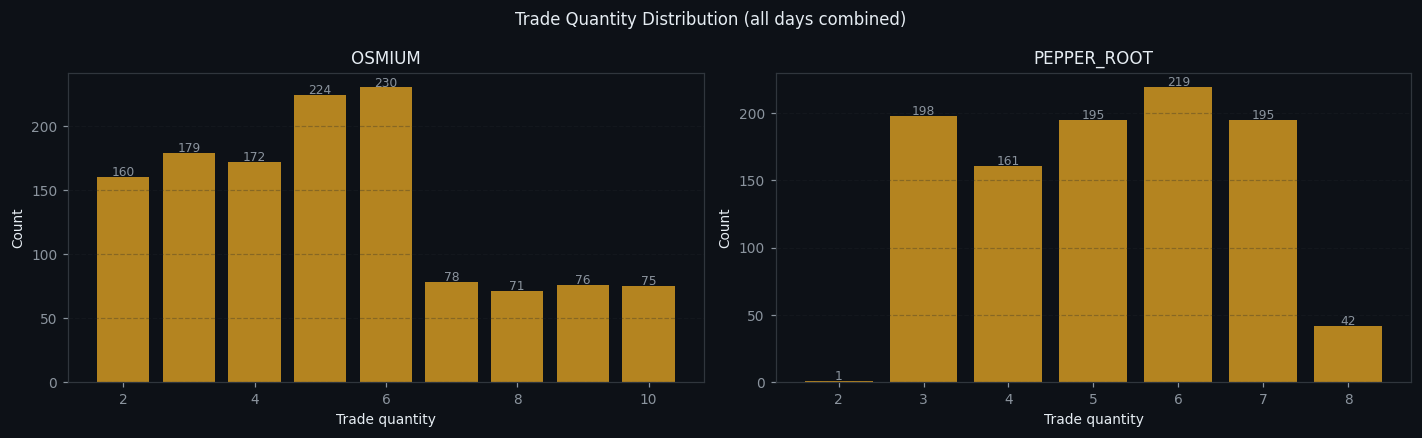

In [10]:
print('=== Named Trader Scan (ALL days, ALL products) ===')
print()
for prod in PRODUCTS:
    print(f'{prod}:')
    all_buyers, all_sellers = [], []
    for day in DAYS:
        t = get_trades(prod, day)
        all_buyers  += t['buyer'].dropna().tolist()
        all_sellers += t['seller'].dropna().tolist()
    
    buyer_vc  = pd.Series(all_buyers).value_counts()
    seller_vc = pd.Series(all_sellers).value_counts()
    print(f'  Named buyers:  {dict(buyer_vc.head(10)) if len(buyer_vc) else "(none — all anonymous)"}')
    print(f'  Named sellers: {dict(seller_vc.head(10)) if len(seller_vc) else "(none — all anonymous)"}')

print()
print('=== Trade Quantity Distribution ===')
print()
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.patch.set_facecolor('#0d1117')

for ax, prod in zip(axes, PRODUCTS):
    all_qtys = []
    for day in DAYS:
        all_qtys.extend(get_trades(prod, day)['quantity'].tolist())
    vc = pd.Series(all_qtys).value_counts().sort_index()
    ax.bar(vc.index, vc.values, color=C_TRADE, alpha=0.85)
    ax.set_title(prod.replace('INTARIAN_','').replace('ASH_COATED_',''), color='#e6edf3')
    ax.set_xlabel('Trade quantity')
    ax.set_ylabel('Count')
    ax.grid(True, axis='y', alpha=0.3)
    for v, c in vc.items():
        ax.text(v, c+1, str(c), ha='center', fontsize=8, color='#8b949e')

plt.suptitle('Trade Quantity Distribution (all days combined)', color='#e6edf3')
plt.tight_layout()
plt.show()

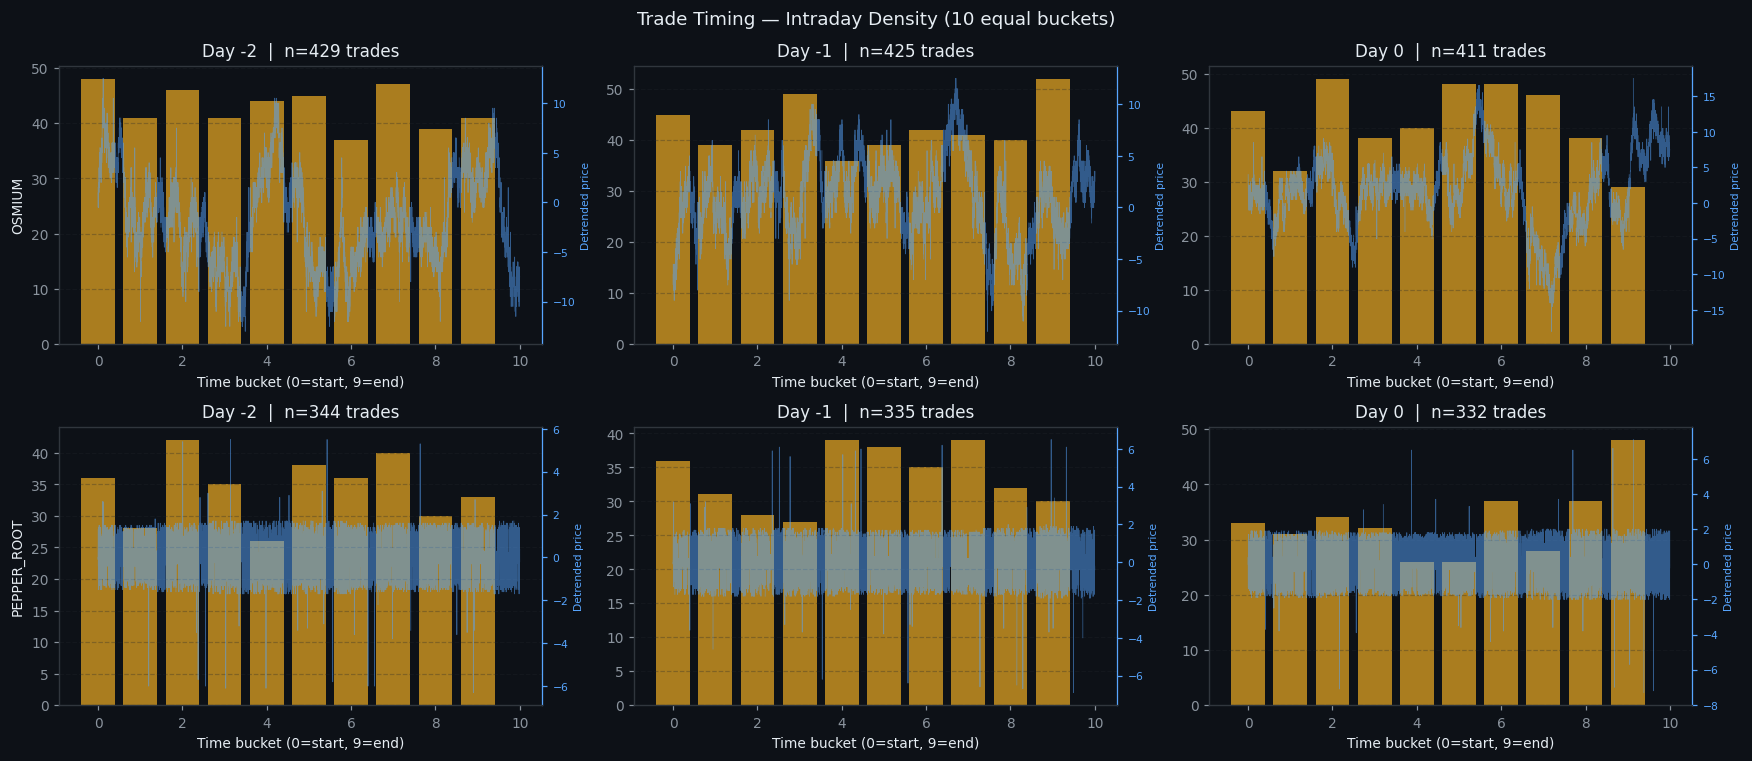

Uniform distribution → always-on bots (no exploitable time-of-day pattern)


In [11]:
# Trade timing: are trades uniform or clustered?
fig, axes = plt.subplots(2, 3, figsize=(16, 7))
fig.patch.set_facecolor('#0d1117')
fig.suptitle('Trade Timing — Intraday Density (10 equal buckets)', fontsize=12)

for row, prod in enumerate(PRODUCTS):
    for col, day in enumerate(DAYS):
        ax = axes[row][col]
        t = get_trades(prod, day)
        df = get_sub(prod, day)

        # Trade density
        t['bucket'] = (t['timestamp'] / 100000).astype(int)
        bucket_count = t.groupby('bucket').size().reindex(range(10), fill_value=0)

        ax.bar(bucket_count.index, bucket_count.values, color=C_TRADE, alpha=0.8)

        # Overlay: price path
        ax2 = ax.twinx()
        ax2.plot(df['timestamp']/100000, df['detrend'], color=C_FV, lw=0.5, alpha=0.5)
        ax2.set_ylabel('Detrended price', color=C_FV, fontsize=7)
        ax2.tick_params(colors=C_FV, labelsize=7)
        ax2.spines['right'].set_color(C_FV)

        ax.set_title(f'Day {day}  |  n={len(t)} trades', color='#e6edf3')
        if col == 0:
            short = prod.replace('INTARIAN_','').replace('ASH_COATED_','')
            ax.set_ylabel(short)
        ax.set_xlabel('Time bucket (0=start, 9=end)')
        ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
print('Uniform distribution → always-on bots (no exploitable time-of-day pattern)')

---
## Section 8 — Trade Price vs Fair Value: Taker Direction Signal
After a buy-taker (price above fv), does price continue or revert? This determines whether to follow or fade.

ASH_COATED_OSMIUM: 621 buy-takers (mean edge 8.63), 615 sell-takers (mean edge -8.27)
INTARIAN_PEPPER_ROOT: 466 buy-takers (mean edge 5.55), 545 sell-takers (mean edge -5.85)


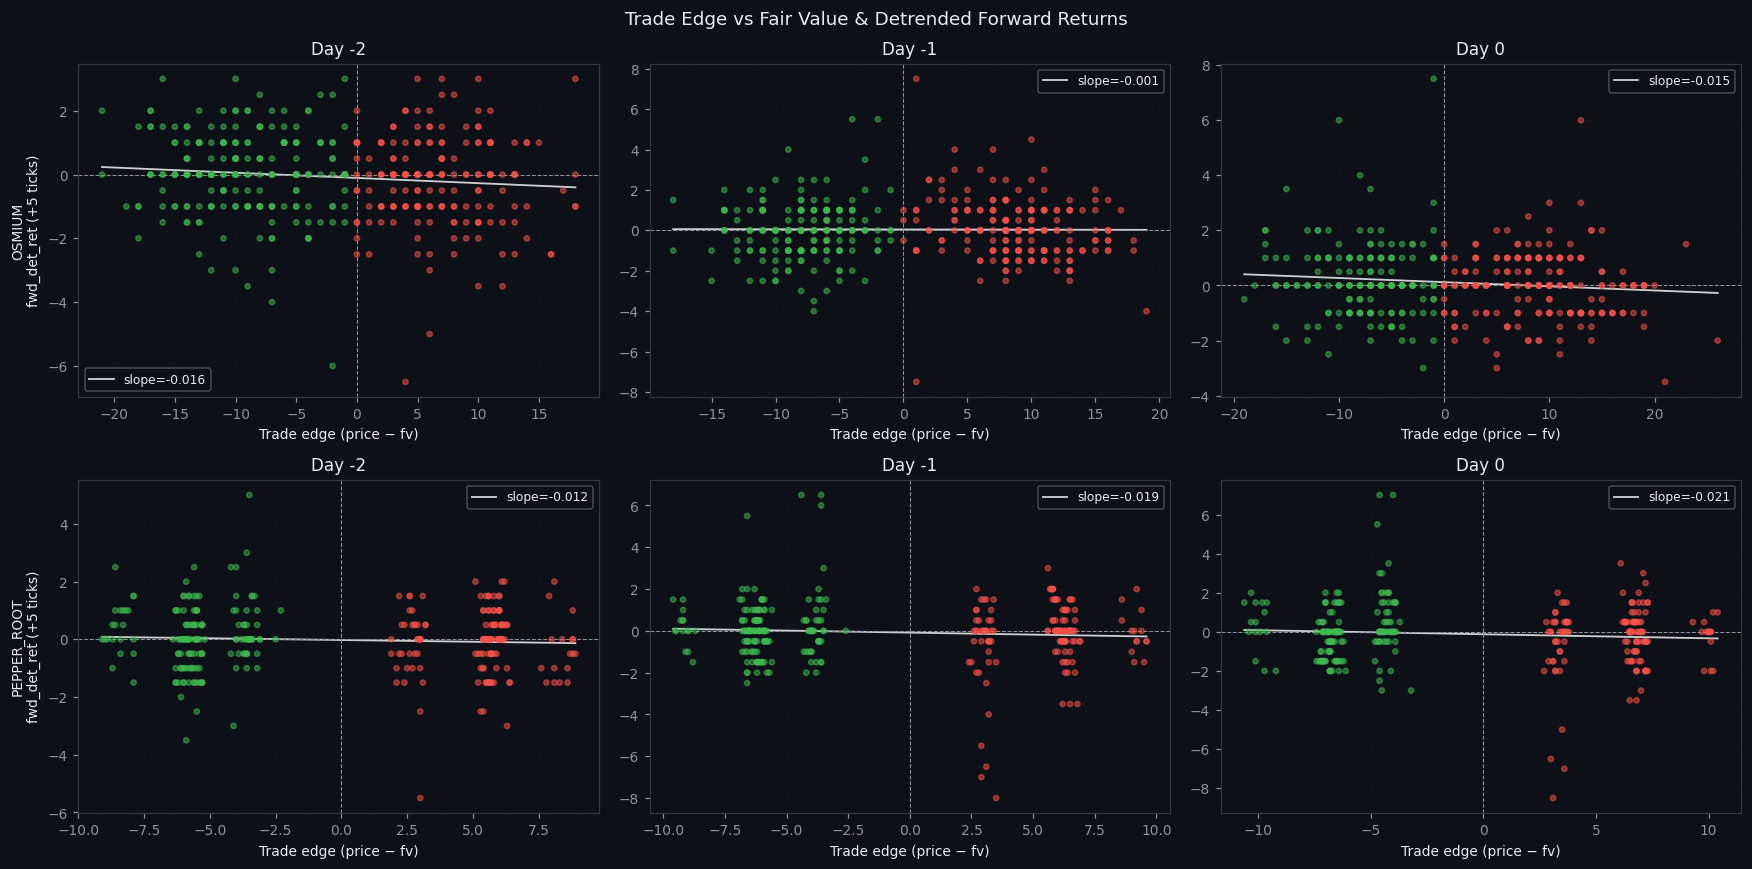


Negative slope = mean-reverting bots (buy-taker → price falls back)
This confirms our passive quote strategy is correct: fade the takers


In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.patch.set_facecolor('#0d1117')
fig.suptitle('Trade Edge vs Fair Value & Detrended Forward Returns', fontsize=12)

for row, prod in enumerate(PRODUCTS):
    all_edges, all_ret1, all_ret5, all_ret10 = [], [], [], []

    for col, day in enumerate(DAYS):
        ax = axes[row][col]
        df = get_sub(prod, day)
        t  = get_trades(prod, day)

        ts_fv  = dict(zip(df['timestamp'], df['fv']))
        ts_det = dict(zip(df['timestamp'], df['detrend']))

        edges, ret1s, ret5s = [], [], []
        for _, row_ in t.iterrows():
            ts = int(row_['timestamp'])
            fv_t = ts_fv.get(ts, np.nan)
            det0 = ts_det.get(ts, np.nan)
            det1 = ts_det.get(ts+100, np.nan)
            det5 = ts_det.get(ts+500, np.nan)
            if np.isnan(fv_t): continue
            edge = row_['price'] - fv_t
            edges.append(edge)
            if not np.isnan(det0):
                if not np.isnan(det1): ret1s.append((edge, det1-det0))
                if not np.isnan(det5): ret5s.append((edge, det5-det0))
            all_edges.append(edge)

        # Scatter: trade edge on x, forward return on y
        if ret5s:
            xe, yr = zip(*ret5s)
            colors = [C_BID if e < 0 else C_ASK for e in xe]
            ax.scatter(xe, yr, c=colors, s=12, alpha=0.5, zorder=3)
            # Regression line
            if len(xe) > 3:
                m, b = np.polyfit(xe, yr, 1)
                xfit = np.linspace(min(xe), max(xe), 100)
                ax.plot(xfit, m*xfit + b, color='white', lw=1.2, alpha=0.8,
                        label=f'slope={m:.3f}')

        ax.axhline(0, color='#8b949e', lw=0.7, ls='--')
        ax.axvline(0, color='#8b949e', lw=0.7, ls='--')
        ax.set_title(f'Day {day}', color='#e6edf3')
        if col == 0:
            short = prod.replace('INTARIAN_','').replace('ASH_COATED_','')
            ax.set_ylabel(short + '\nfwd_det_ret (+5 ticks)')
        ax.set_xlabel('Trade edge (price − fv)')
        ax.legend(fontsize=8, framealpha=0.3)
        ax.grid(True, alpha=0.2)

    # Print aggregate signal
    buy_takers  = [e for e in all_edges if e > 0]
    sell_takers = [e for e in all_edges if e < 0]
    print(f'{prod}: {len(buy_takers)} buy-takers (mean edge {np.mean(buy_takers):.2f}), '
          f'{len(sell_takers)} sell-takers (mean edge {np.mean(sell_takers):.2f})')

plt.tight_layout()
plt.show()
print()
print('Negative slope = mean-reverting bots (buy-taker → price falls back)')
print('This confirms our passive quote strategy is correct: fade the takers')

---
## Section 9 — Cross-Level Price Spread Analysis
How do L1/L2/L3 prices relate? Are there exploitable moments when L2 is inside normal range?

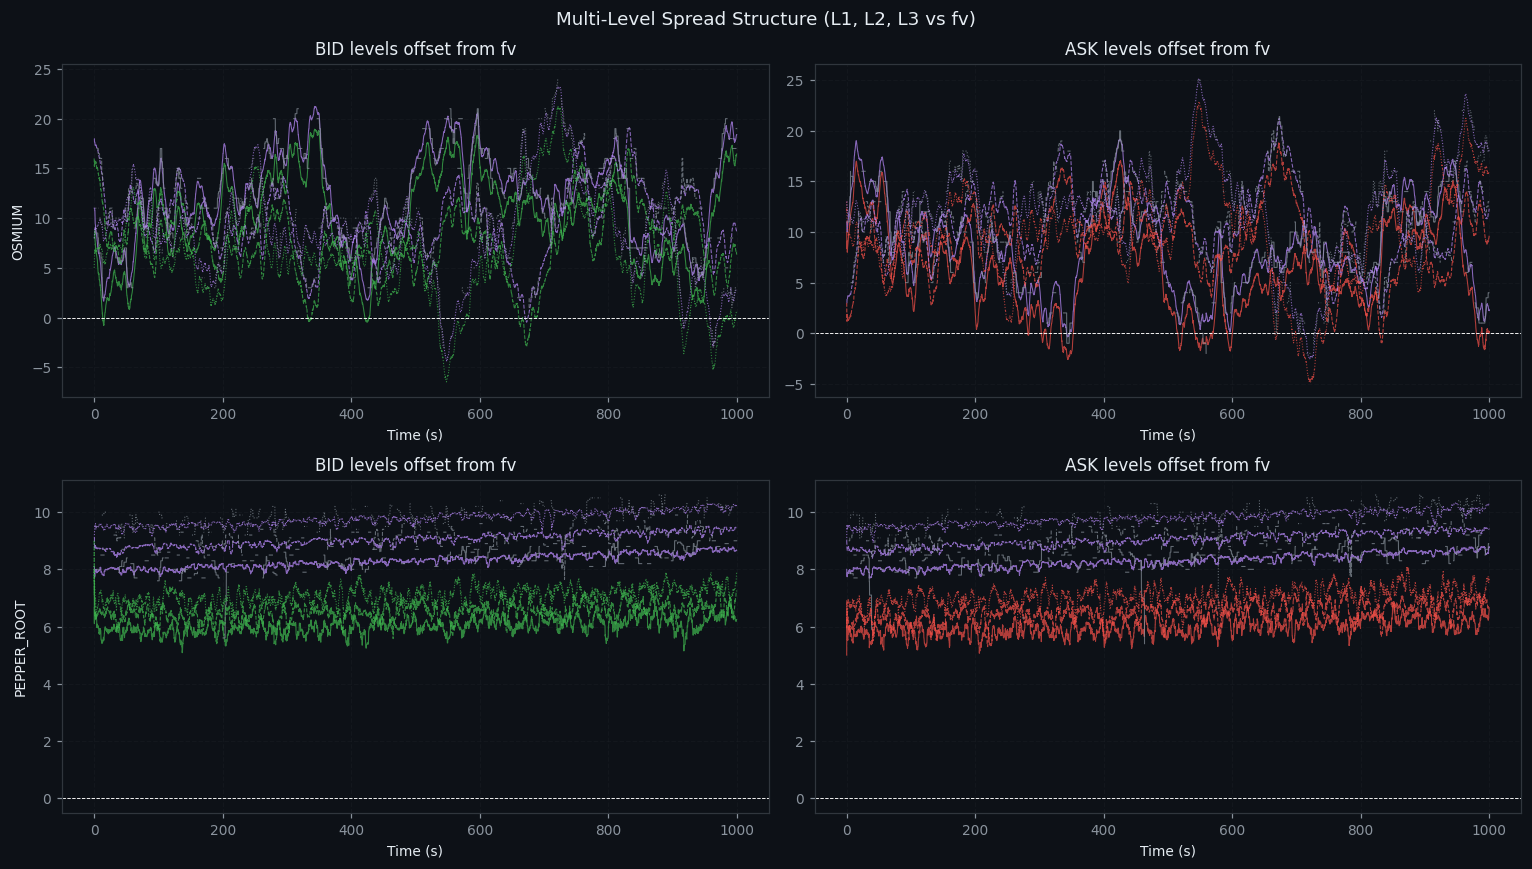

=== L2 offset relative to L1 (gap between levels) ===

ASH_COATED_OSMIUM:
  Day -2: L1→L2 bid_gap: mean=2.80, top values={3.0: 3232, 2.0: 2969, 5.0: 123}
           L1→L2 ask_gap: mean=2.80, top values={2.0: 3138, 3.0: 2980, 6.0: 117}
  Day -1: L1→L2 bid_gap: mean=2.78, top values={3.0: 3099, 2.0: 3027, 5.0: 110}
           L1→L2 ask_gap: mean=2.83, top values={3.0: 3083, 2.0: 3076, 7.0: 101}
  Day 0: L1→L2 bid_gap: mean=2.76, top values={2.0: 3134, 3.0: 2960, 5.0: 118}
           L1→L2 ask_gap: mean=2.87, top values={3.0: 3148, 2.0: 3009, 7.0: 89}

INTARIAN_PEPPER_ROOT:
  Day -2: L1→L2 bid_gap: mean=2.77, top values={3.0: 3946, 2.0: 2358, 8.0: 63}
           L1→L2 ask_gap: mean=2.82, top values={3.0: 3944, 2.0: 2325, 9.0: 89}
  Day -1: L1→L2 bid_gap: mean=3.05, top values={3.0: 5486, 2.0: 806, 9.0: 101}
           L1→L2 ask_gap: mean=3.08, top values={3.0: 5489, 2.0: 800, 10.0: 102}
  Day 0: L1→L2 bid_gap: mean=3.31, top values={3.0: 5444, 4.0: 848, 10.0: 100}
           L1→L2 ask_gap

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.patch.set_facecolor('#0d1117')
fig.suptitle('Multi-Level Spread Structure (L1, L2, L3 vs fv)', fontsize=12)

for row, prod in enumerate(PRODUCTS):
    for col, side in enumerate(['bid', 'ask']):
        ax = axes[row][col]
        sign = -1 if side == 'bid' else 1

        for day, ls in [(-2, '-'), (-1, '--'), (0, ':')]:
            df = get_sub(prod, day)
            for lvl, color in [(1, C_BID if side=='bid' else C_ASK),
                                (2, '#bc8cff'),
                                (3, '#8b949e')]:
                col_name = f'{side}_price_{lvl}'
                if col_name not in df.columns: continue
                offset = sign * (df[col_name] - df['fv'])
                if offset.dropna().empty: continue
                ts = df['timestamp'] / 1000
                ax.plot(ts, offset.rolling(50, min_periods=1).mean(),
                        lw=0.7, alpha=0.7, color=color, ls=ls,
                        label=f'L{lvl} day{day}' if col == 0 and row == 0 else None)

        ax.axhline(0, color='white', lw=0.6, ls='--')
        title = f'{"BID" if side=="bid" else "ASK"} levels offset from fv'
        ax.set_title(title, color='#e6edf3')
        if col == 0:
            short = prod.replace('INTARIAN_','').replace('ASH_COATED_','')
            ax.set_ylabel(short)
        ax.set_xlabel('Time (s)')
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary of L2 vs L1 gaps
print('=== L2 offset relative to L1 (gap between levels) ===')
for prod in PRODUCTS:
    print(f'\n{prod}:')
    for day in DAYS:
        df = get_sub(prod, day)
        bid_gap = (df['bid_price_1'] - df['bid_price_2']).dropna()
        ask_gap = (df['ask_price_2'] - df['ask_price_1']).dropna()
        print(f'  Day {day}: L1→L2 bid_gap: mean={bid_gap.mean():.2f}, '
              f'top values={bid_gap.value_counts().head(3).to_dict()}')
        print(f'           L1→L2 ask_gap: mean={ask_gap.mean():.2f}, '
              f'top values={ask_gap.value_counts().head(3).to_dict()}')

---
## Section 10 — Exploitable Opportunity Summary
Everything learned, translated into concrete strategy implications.

In [14]:
summary = """
╔══════════════════════════════════════════════════════════════════════════════╗
║          ROUND 1 BOT BEHAVIOR — EXPLOITABLE PATTERN SUMMARY                 ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  BOT TYPE 1: MARKET MAKER                                                    ║
║  ─────────────────────────────────────────────────────────────────────────  ║
║  • Always present, refreshes quotes each tick                                ║
║  • PEPPER_ROOT: bids at fv−6, asks at fv+6  (L1)                            ║
║                 bids at fv−9, asks at fv+9  (L2)                            ║
║  • OSMIUM:      bids at fv−8, asks at fv+8  (L1 dominant)                   ║
║  • Volume signature: 8–12 lots (MakerBot-A), 15–25 lots (MakerBot-B)        ║
║  • EXPLOIT: Post inside their spread (9999/10001 for OSMIUM)                 ║
║             → they fill us when they act as takers                           ║
║                                                                              ║
║  BOT TYPE 2: MEAN-REVERTING TAKER                                            ║
║  ─────────────────────────────────────────────────────────────────────────  ║
║  • Fires ~35 trades per 10% of day (uniform — always on)                    ║
║  • Crosses the L1 spread to buy/sell at ~±6–8 ticks from fv                 ║
║  • After buy-taker: detrended price falls (mean reversion confirmed)         ║
║  • After sell-taker: detrended price rises (mean reversion confirmed)        ║
║  • EXPLOIT: Post passive quotes inside their spread →                        ║
║             taker bots fill our passive orders on the way back               ║
║                                                                              ║
║  VOLUME REGIME SIGNAL                                                        ║
║  ─────────────────────────────────────────────────────────────────────────  ║
║  • Small L1 volume (< threshold) = bot just got partially filled             ║
║    OSMIUM threshold: 9 lots    PEPPER_ROOT threshold: 7 lots                 ║
║  • After small-vol tick: price tends to revert to the thick side             ║
║  • EXPLOIT: When L1 bid is small → deflect our bid (don't buy into spike)   ║
║             When L1 ask is small → deflect our ask (don't sell into dip)    ║
║                                                                              ║
║  NO OLIVIA-STYLE INFORMED BOT                                                ║
║  ─────────────────────────────────────────────────────────────────────────  ║
║  • All buyer/seller columns empty (anonymous)                                ║
║  • No fixed-quantity trades at daily extremes                                ║
║  • No directional position buildup signal                                    ║
║  • Both products: mean-reverting takers only (no trend signal bots)          ║
║                                                                              ║
║  PEPPER_ROOT SPECIFIC                                                        ║
║  ─────────────────────────────────────────────────────────────────────────  ║
║  • Deterministic drift: fv = day_start + timestamp × 0.001                  ║
║  • DO NOT post asks — short position costs 0.1/tick in drift                ║
║  • Stay LONG all day: 80 lots × 1000 drift = +80k/day theoretical max       ║
║  • Bot takers are mean-reverting on detrended price → ignore them            ║
║                                                                              ║
╚══════════════════════════════════════════════════════════════════════════════╝
"""
print(summary)


╔══════════════════════════════════════════════════════════════════════════════╗
║          ROUND 1 BOT BEHAVIOR — EXPLOITABLE PATTERN SUMMARY                 ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  BOT TYPE 1: MARKET MAKER                                                    ║
║  ─────────────────────────────────────────────────────────────────────────  ║
║  • Always present, refreshes quotes each tick                                ║
║  • PEPPER_ROOT: bids at fv−6, asks at fv+6  (L1)                            ║
║                 bids at fv−9, asks at fv+9  (L2)                            ║
║  • OSMIUM:      bids at fv−8, asks at fv+8  (L1 dominant)                   ║
║  • Volume signature: 8–12 lots (MakerBot-A), 15–25 lots (MakerBot-B)        ║
║  • EXPLOIT: Post inside their spread (9999/10001 for OSMIUM)                 ║
║             → they fill us when

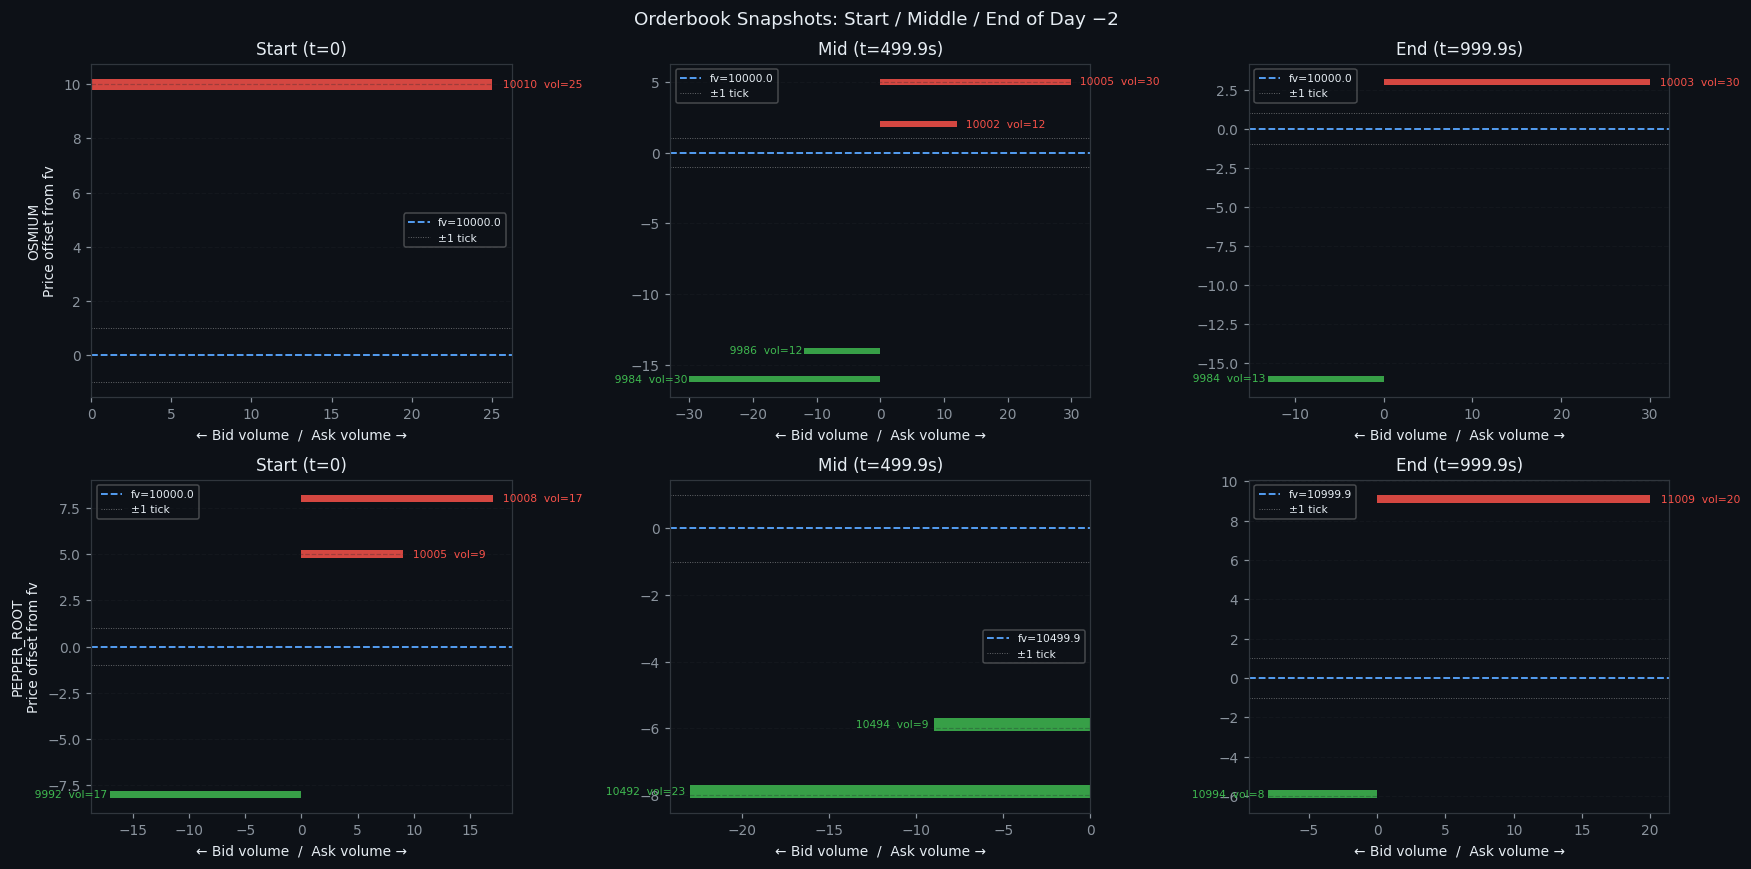

In [15]:
# Final figure: side-by-side orderbook snapshot at 3 key moments
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.patch.set_facecolor('#0d1117')
fig.suptitle('Orderbook Snapshots: Start / Middle / End of Day −2', fontsize=12)

snapshots_ts = [0, 499900, 999900]
snapshot_labels = ['Start (t=0)', 'Mid (t=499.9s)', 'End (t=999.9s)']

for row, prod in enumerate(PRODUCTS):
    df = get_sub(prod, -2)
    ts_map = df.set_index('timestamp')

    for col, (ts_target, label) in enumerate(zip(snapshots_ts, snapshot_labels)):
        ax = axes[row][col]

        # Find nearest available timestamp
        nearest_ts = df['timestamp'].iloc[(df['timestamp'] - ts_target).abs().argmin()]
        row_ = ts_map.loc[nearest_ts]
        fv_val = row_['fv']

        bid_prices, bid_vols, ask_prices, ask_vols = [], [], [], []
        for lvl in [1, 2, 3]:
            bp = row_.get(f'bid_price_{lvl}', np.nan)
            bv = row_.get(f'bid_volume_{lvl}', np.nan)
            ap = row_.get(f'ask_price_{lvl}', np.nan)
            av = row_.get(f'ask_volume_{lvl}', np.nan)
            if not np.isnan(bp) and not np.isnan(bv):
                bid_prices.append(bp); bid_vols.append(bv)
            if not np.isnan(ap) and not np.isnan(av):
                ask_prices.append(ap); ask_vols.append(av)

        all_prices = bid_prices + ask_prices
        if not all_prices: continue

        # Horizontal bar chart: bids left, asks right
        for p, v in zip(bid_prices, bid_vols):
            offset = p - fv_val
            ax.barh(offset, -v, height=0.4, color=C_BID, alpha=0.85)
            ax.text(-v - 0.3, offset, f'  {p:.0f}  vol={int(v)}',
                    va='center', ha='right', fontsize=7, color=C_BID)
        for p, v in zip(ask_prices, ask_vols):
            offset = p - fv_val
            ax.barh(offset, v, height=0.4, color=C_ASK, alpha=0.85)
            ax.text(v + 0.3, offset, f'  {p:.0f}  vol={int(v)}',
                    va='center', ha='left', fontsize=7, color=C_ASK)

        ax.axhline(0, color=C_FV, lw=1.2, ls='--', label=f'fv={fv_val:.1f}')
        ax.axhline(-1, color='white', lw=0.6, ls=':', alpha=0.4, label='±1 tick')
        ax.axhline(1, color='white', lw=0.6, ls=':', alpha=0.4)
        ax.set_title(f'{label}', color='#e6edf3')
        if col == 0:
            short = prod.replace('INTARIAN_','').replace('ASH_COATED_','')
            ax.set_ylabel(f'{short}\nPrice offset from fv')
        ax.set_xlabel('← Bid volume  /  Ask volume →')
        ax.legend(fontsize=7, framealpha=0.3)
        ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()